# Estimador de RUL — Versión simplificada

**XJTU-SY Bearing Dataset** (rodamientos `1_1`, `1_2`, `1_3`, condición 35 Hz / 12 kN)

Este notebook realiza una demostración simplificada del funcionamiento del modelo usando uno del tipo random forest para realizar sus predicciones. Para ejecutarlo correctamente se debe colocar en la carpeta "**/sample_data**" los archivos "**model.pkl**" y "**datos_muestra.csv**". Al finalizar la ejecución el código muestra una grafica de correlación entre valor predicho (en rojo) vs valor real (linea punteada) para el caso del rodamiento 1_2. Posteriormente se muestra la predicción que se realiza para algunos instantes tomados para entrenamiento tanto del rodamiento 1_1 como 1_2 y 1_3.



**BLOQUE 1**: Predicción con dataset simplificado y grafica de correlación entre valor predicho vs valor real



Filas totales: 100
split
train    70
test     30
Name: count, dtype: int64
bearing
1_2    54
1_3    33
1_1    13
Name: count, dtype: int64
            MAE  n_filas
split                   
test   6.386234       30
train  1.849483       70
Rodamiento 1_2 — minuto 129
  RUL real:      32.0 min
  RUL predicho:  23.9 min
  Error:         8.1 min (13.5%)

Rodamiento 1_2 — minuto 159
  RUL real:      2.0 min
  RUL predicho:  6.4 min
  Error:         4.4 min (7.3%)

Rodamiento 1_2 — minuto 141
  RUL real:      20.0 min
  RUL predicho:  16.3 min
  Error:         3.7 min (6.1%)

Rodamiento 1_2 — minuto 138
  RUL real:      23.0 min
  RUL predicho:  17.4 min
  Error:         5.6 min (9.3%)

Rodamiento 1_2 — minuto 157
  RUL real:      4.0 min
  RUL predicho:  14.4 min
  Error:         10.4 min (17.4%)



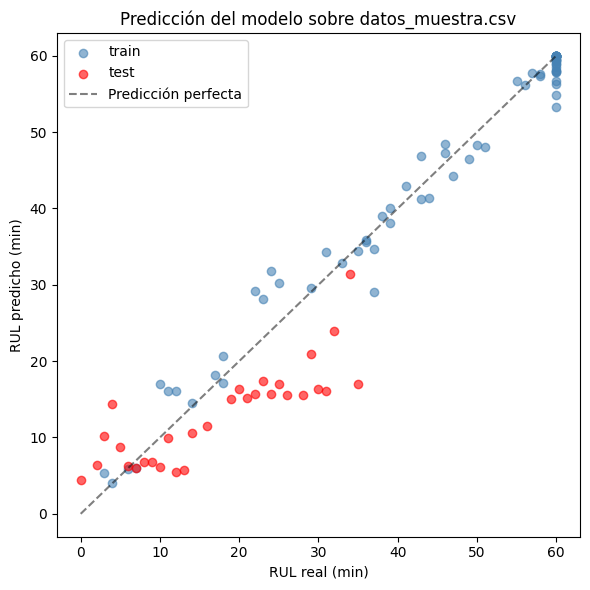

=== Comparativa: RUL real vs. predicho (10 casos, tramo fuera de muestra) ===

Rodamiento  Minuto (t)  RUL real (min)  RUL predicho (min)  Error absoluto (min)  Error (%)
       1_2         129              32                23.9                   8.1       13.5
       1_2         138              23                17.4                   5.6        9.3
       1_2         139              22                15.7                   6.3       10.5
       1_2         141              20                16.3                   3.7        6.1
       1_2         148              13                 5.7                   7.3       12.1
       1_2         153               8                 6.8                   1.2        2.0
       1_2         155               6                 6.3                   0.3        0.4
       1_2         157               4                14.4                  10.4       17.4
       1_2         158               3                10.2                   7.2       12.0
 

In [ ]:
#-----ESTIMADOR DE RUL DE RODAMIENTO (VERSION SIMPLIFICADA)-----------------

#---------------------BLOQUE 1---------------------
import pandas as pd
import joblib

# Cargar el modelo y la muestra
paquete = joblib.load('/content/sample_data/model.pkl')
modelo = paquete['modelo']
cols = paquete['features']
rul_cap = paquete.get('rul_cap', 60)

datos = pd.read_csv('/content/sample_data/datos_muestra.csv')

print('Filas totales:', len(datos))
print(datos['split'].value_counts())
print(datos['bearing'].value_counts())
datos.head()

#---------------------BLOQUE 2---------------------
datos['rul_predicho'] = modelo.predict(datos[cols])
datos['error_abs'] = (datos['rul_predicho'] - datos['rul_capped']).abs()

# Separar por split para no mezclar in-sample con fuera de muestra
resumen = datos.groupby('split').agg(
    MAE=('error_abs', 'mean'),
    n_filas=('error_abs', 'count')
)
print(resumen)

#---------------------BLOQUE 3---------------------
# Muestra 5 ejemplos del tramo de TEST (fuera de muestra), que es tu resultado auditado
ejemplos_test = datos[datos['split'] == 'test'].sample(5, random_state=0)

for _, fila in ejemplos_test.iterrows():
    print(f"Rodamiento {fila['bearing']} — minuto {int(fila['t'])}")
    print(f"  RUL real:      {fila['rul_capped']:.1f} min")
    print(f"  RUL predicho:  {fila['rul_predicho']:.1f} min")
    print(f"  Error:         {fila['error_abs']:.1f} min ({fila['error_abs']/rul_cap*100:.1f}%)")
    print()

#---------------------BLOQUE 4---------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
colores = {'train': 'steelblue', 'test': 'red'}
for split, color in colores.items():
    sub = datos[datos.split == split]
    ax.scatter(sub['rul_capped'], sub['rul_predicho'], alpha=0.6, color=color, label=split)

ax.plot([0, rul_cap], [0, rul_cap], 'k--', alpha=0.5, label='Predicción perfecta')
ax.set_xlabel('RUL real (min)')
ax.set_ylabel('RUL predicho (min)')
ax.set_title('Predicción del modelo sobre datos_muestra.csv')
ax.legend()
plt.tight_layout()
plt.show()

#---------------------BLOQUE 5---------------------
import pandas as pd

# Selecciona 10 casos del tramo de TEST (fuera de muestra) — el resultado auditado y más defendible
n_casos = min(10, len(datos[datos.split == 'test']))
casos = datos[datos.split == 'test'].sample(n_casos, random_state=0).sort_values('t')

resultados_comparacion = []
for _, caso in casos.iterrows():
    pred = modelo.predict(pd.DataFrame([caso[cols]]))[0]
    real = caso['rul_capped']
    error_abs = abs(pred - real)
    error_pct = error_abs / rul_cap * 100

    resultados_comparacion.append({
        'Rodamiento': caso['bearing'],
        'Minuto (t)': int(caso['t']),
        'RUL real (min)': round(real, 1),
        'RUL predicho (min)': round(pred, 1),
        'Error absoluto (min)': round(error_abs, 1),
        'Error (%)': round(error_pct, 1),
    })

tabla_comparativa = pd.DataFrame(resultados_comparacion)
print(f"=== Comparativa: RUL real vs. predicho ({n_casos} casos, tramo fuera de muestra) ===\n")
print(tabla_comparativa.to_string(index=False))

print(f"\nMAE promedio de estos {n_casos} casos: {tabla_comparativa['Error absoluto (min)'].mean():.2f} min")
print(f"Error % promedio: {tabla_comparativa['Error (%)'].mean():.1f}%")

**BLOQUE 2**: Visualización de predicciones con valores usados durante entrenamiento (Según conceptos aprendidos en el curso deberia ser casi identico al valor real)



In [1]:
import pandas as pd

# ============================================================
# BLOQUE 2: Ejemplos IN-SAMPLE (1_1, 1_3 completos + 70% inicial de 1_2)
# ============================================================
print("=" * 70)
print("BLOQUE 2: EJEMPLOS IN-SAMPLE (datos vistos en entrenamiento)")
print("Incluye: 1_1 completo, 1_3 completo, y el tramo inicial (70%) de 1_2.")
print("Estos NO son evidencia de generalización, solo muestran que el")
print("modelo funciona correctamente sobre datos conocidos.")
print("=" * 70)

n_insample = min(10, len(datos[datos.split == 'train']))
casos_insample = datos[datos.split == 'train'].sample(n_insample, random_state=0).sort_values(['bearing', 't'])

resultados_insample = []
for _, caso in casos_insample.iterrows():
    pred = modelo.predict(pd.DataFrame([caso[cols]]))[0]
    real = caso['rul_capped']
    error_abs = abs(pred - real)
    resultados_insample.append({
        'Rodamiento': caso['bearing'],
        'Minuto (t)': int(caso['t']),
        'RUL real (min)': round(real, 1),
        'RUL predicho (min)': round(pred, 1),
        'Error absoluto (min)': round(error_abs, 1),
        'Error (%)': round(error_abs / rul_cap * 100, 1),
    })

tabla_insample = pd.DataFrame(resultados_insample)
print(tabla_insample.to_string(index=False))
print(f"\nMAE promedio (in-sample): {tabla_insample['Error absoluto (min)'].mean():.2f} min")
print(f"Error % promedio (in-sample): {tabla_insample['Error (%)'].mean():.1f}%")
print(f"\nRodamientos incluidos en esta muestra: {sorted(tabla_insample['Rodamiento'].unique())}")

BLOQUE 2: EJEMPLOS IN-SAMPLE (datos vistos en entrenamiento)
Incluye: 1_1 completo, 1_3 completo, y el tramo inicial (70%) de 1_2.
Estos NO son evidencia de generalización, solo muestran que el
modelo funciona correctamente sobre datos conocidos.


NameError: name 'datos' is not defined

**BLOQUE 3**: Visualización de predicciones con el 30% de los valores restantes de 1_2 que no formaron parte de la muestra de entrenamiento.



In [2]:
# ============================================================
# BLOQUE 3: Ejemplos FUERA DE MUESTRA (exclusivamente 1_2 — tramo test)
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 3: EJEMPLOS FUERA DE MUESTRA (1_2 — tramo final, nunca visto)")
print("Este es el resultado validado y auditado del proyecto.")
print("=" * 70)

n_test = min(10, len(datos[datos.split == 'test']))
casos_test = datos[datos.split == 'test'].sample(n_test, random_state=0).sort_values('t')

resultados_test = []
for _, caso in casos_test.iterrows():
    pred = modelo.predict(pd.DataFrame([caso[cols]]))[0]
    real = caso['rul_capped']
    error_abs = abs(pred - real)
    resultados_test.append({
        'Rodamiento': caso['bearing'],
        'Minuto (t)': int(caso['t']),
        'RUL real (min)': round(real, 1),
        'RUL predicho (min)': round(pred, 1),
        'Error absoluto (min)': round(error_abs, 1),
        'Error (%)': round(error_abs / rul_cap * 100, 1),
    })

tabla_test = pd.DataFrame(resultados_test)
print(tabla_test.to_string(index=False))
print(f"\nMAE promedio (fuera de muestra): {tabla_test['Error absoluto (min)'].mean():.2f} min")
print(f"Error % promedio (fuera de muestra): {tabla_test['Error (%)'].mean():.1f}%")


BLOQUE 3: EJEMPLOS FUERA DE MUESTRA (1_2 — tramo final, nunca visto)
Este es el resultado validado y auditado del proyecto.


NameError: name 'datos' is not defined

**CONCLUSIONES FINALES**:
Los resultados observados en esta versión simplificada se corresponden con los resultados obtenidos en la versión completa de este proyecto. También se obtiene el mismo resultado al ejecutar la interfaz aplicativa web en streamlit.

